#### Importance of Clustering algorithms 
They are important because , they find the hidden patterns in the data and group then into the similar clusters , without having the predefined labels

Ex:
Customer Segmentation -> Grouping the customers  with similar buying habits

Netflix Recomendation systems -> Recomending the movies based on similar views

#### Labels 
Labels are known as the dependent variable
Unsupervised machine learning doesn't uses the labels 

#### Silhouette Scoring
Silhouette Scoring is the distance between a point in the cluster to all other points in the cluster
It tells how well the clusters have formed 

It typically lies in between +1 and -1 
-> The more the score to 1 the better the model is 


#### Inertia 
Inertia_ is the Sum Of Squares Within the Clusters  WCSS

Which means the distance between the centriod and the points and square them

#### Random State =42
Random state is defined beacuse the same rows will go into the training and test sets every time
IF  you don't specify the random state you might get different results every time you run the code

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [4]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [5]:
X

array([[-8.85173162, -7.22601063],
       [ 2.00763019, -2.33564364],
       [ 0.51520112,  4.82830547],
       ...,
       [ 2.06611951, -3.60497342],
       [ 1.61356391, -2.27760767],
       [ 3.29474023, -4.76746226]], shape=(1000, 2))

In [6]:
y

array([0, 2, 1, 2, 2, 2, 2, 1, 0, 0, 2, 1, 1, 2, 2, 2, 1, 0, 2, 1, 2, 1,
       2, 0, 0, 0, 0, 2, 2, 2, 2, 1, 0, 2, 2, 0, 0, 1, 1, 2, 1, 1, 2, 1,
       1, 0, 2, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 2, 1,
       0, 0, 1, 0, 0, 2, 0, 1, 1, 0, 0, 1, 2, 1, 1, 2, 0, 1, 1, 0, 1, 2,
       0, 0, 2, 2, 2, 0, 1, 1, 2, 1, 0, 2, 0, 2, 1, 0, 0, 0, 2, 0, 0, 2,
       2, 0, 1, 0, 2, 1, 2, 0, 1, 0, 2, 0, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1,
       0, 1, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, 1, 2, 0, 1, 2, 2, 0, 1,
       0, 0, 2, 1, 1, 0, 0, 2, 2, 2, 1, 0, 1, 1, 0, 0, 0, 0, 2, 2, 1, 0,
       2, 0, 2, 1, 2, 1, 1, 0, 2, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 2, 0, 2,
       2, 1, 0, 2, 0, 2, 1, 2, 0, 1, 0, 1, 2, 0, 1, 2, 1, 2, 0, 2, 2, 1,
       1, 1, 2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 2, 0, 1, 0, 2, 1, 0, 0, 2, 0,
       1, 1, 0, 2, 1, 1, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 2, 2, 1, 1, 2, 2,
       2, 0, 0, 2, 0, 2, 2, 1, 0, 2, 2, 2, 1, 0, 2, 1, 2, 1, 2, 0, 0, 2,
       2, 0, 2, 1, 0, 2, 1, 2, 2, 0, 0, 1, 1, 0, 1,

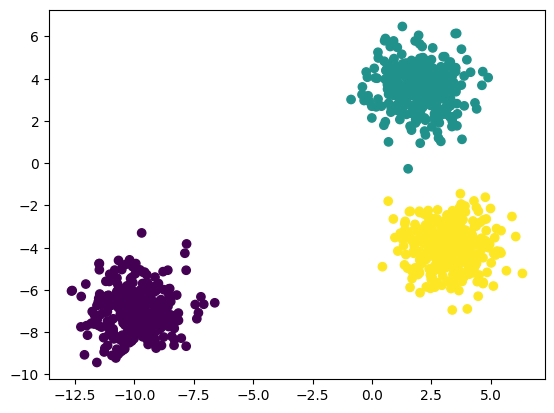

In [8]:
plt.scatter(X[:,0],X[:,1],c=y)      #C is the target value 

In [9]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [11]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [16]:
from sklearn.cluster import KMeans

#### For plotting the elbow curve 
Elbow curve is used to identify the number of clusters needed for the kmeans

In [17]:
wcss=[]

for k in range (1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [18]:
wcss

[1340.0000000000005,
 374.94734028160224,
 52.42712411048265,
 45.335734541420834,
 37.87943494440911,
 30.808455555768482,
 33.085175619855505,
 25.578411468978985,
 23.71147650440352,
 21.307222125574945]

#### Both are same

In [19]:
inertia=[]

for k in range (1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_train_scaled)
    inertia.append(kmeans.inertia_)

In [20]:
inertia

[1340.0000000000005,
 374.94734028160224,
 52.42712411048265,
 44.9475779320358,
 37.88109826016626,
 35.00347596076095,
 33.377461898196884,
 25.565256907349344,
 23.230711544257417,
 21.300507942808416]

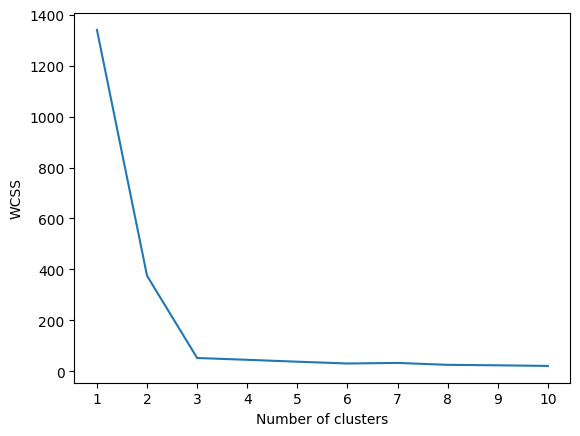

In [28]:
#Find the Elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [29]:
kmeans=KMeans(n_clusters=3,random_state=42)

In [30]:
kmeans.fit_predict(X_train_scaled)

array([1, 1, 0, 0, 1, 1, 0, 2, 0, 2, 1, 0, 0, 0, 1, 0, 2, 1, 0, 2, 2, 0,
       1, 1, 0, 2, 2, 2, 0, 0, 1, 1, 0, 1, 2, 0, 1, 1, 2, 1, 1, 0, 0, 0,
       0, 0, 1, 2, 0, 2, 1, 0, 0, 2, 2, 0, 0, 1, 0, 0, 1, 2, 2, 1, 1, 1,
       1, 1, 0, 0, 1, 2, 0, 2, 2, 2, 0, 1, 2, 2, 2, 2, 2, 0, 1, 1, 2, 0,
       1, 1, 0, 0, 2, 0, 0, 0, 2, 2, 0, 1, 0, 0, 1, 2, 0, 2, 2, 2, 0, 2,
       2, 0, 0, 1, 1, 2, 2, 0, 1, 0, 2, 2, 0, 0, 1, 0, 2, 1, 1, 1, 2, 1,
       0, 2, 2, 1, 0, 2, 0, 0, 0, 0, 1, 1, 1, 2, 1, 0, 2, 2, 0, 2, 2, 1,
       1, 2, 0, 1, 2, 0, 0, 2, 2, 1, 0, 0, 0, 1, 0, 0, 2, 1, 1, 2, 2, 0,
       1, 2, 1, 2, 1, 0, 2, 0, 1, 2, 0, 2, 2, 0, 0, 0, 2, 2, 0, 1, 2, 0,
       1, 1, 1, 2, 2, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 2, 1, 2, 2, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 2, 0,
       0, 2, 1, 1, 1, 0, 2, 1, 0, 2, 1, 0, 0, 2, 1, 0, 2, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 2, 1, 1, 2, 1, 2, 0, 2, 2, 0, 0, 0, 0, 2, 1, 2, 2,
       1, 1, 0, 1, 2, 2, 1, 1, 2, 1, 1, 0, 2, 0, 2,

In [31]:
y_pred=kmeans.predict(X_test_scaled)

In [32]:
y_pred

array([1, 0, 2, 1, 2, 2, 2, 1, 1, 0, 2, 1, 2, 1, 1, 2, 0, 0, 0, 2, 1, 2,
       0, 2, 0, 1, 0, 0, 1, 1, 0, 1, 2, 0, 2, 0, 2, 2, 0, 2, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 2, 2, 2, 2, 1, 1, 0, 2, 0, 2, 2, 1, 1, 1, 2, 2, 2,
       0, 2, 1, 0, 1, 1, 2, 1, 2, 2, 2, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 2,
       1, 2, 2, 1, 2, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 0, 0, 2, 2, 0, 2, 1, 1, 2, 2, 0, 0, 2, 2, 0, 0, 2,
       1, 1, 0, 1, 0, 0, 1, 1, 2, 2, 2, 2, 2, 2, 0, 1, 2, 2, 0, 2, 1, 2,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 2, 2, 2, 1, 2, 1, 0, 0, 0, 2, 0,
       1, 0, 2, 1, 0, 2, 0, 1, 1, 1, 0, 2, 0, 1, 2, 2, 2, 2, 0, 0, 2, 1,
       2, 0, 0, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 0, 2, 1, 0, 0, 2, 1, 0, 1,
       2, 2, 0, 1, 2, 2, 0, 0, 1, 0, 1, 2, 0, 2, 0, 2, 0, 2, 1, 0, 0, 2,
       2, 1, 0, 0, 0, 2, 2, 0, 1, 0, 2, 0, 2, 2, 1, 2, 0, 0, 1, 0, 2, 1,
       0, 0, 2, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 0, 1, 1, 2, 1, 1, 1, 2,
       2, 2, 1, 2, 0, 0, 1, 1, 0, 2, 2, 1, 2, 1, 1,

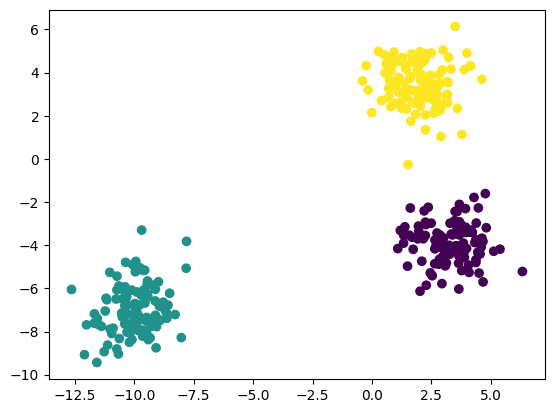

In [33]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

#### To find the number of clusters in manual way
We use kneed module

In [34]:
#To run this install kneed
# -> !pip install kneed

from kneed import KneeLocater

ModuleNotFoundError: No module named 'kneed'

In [43]:
from sklearn.metrics import silhouette_score

In [44]:
silhouette_coefficients=[]

for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    
    silhouette_coefficients.append(score)

In [45]:
silhouette_coefficients

[0.6931880469681886,
 0.8095751754516134,
 0.6489813642448242,
 0.49187313929928467,
 0.48120980601702523,
 0.4797228957409967,
 0.33648347420554736,
 0.32027005569563866,
 0.32641533921636284]

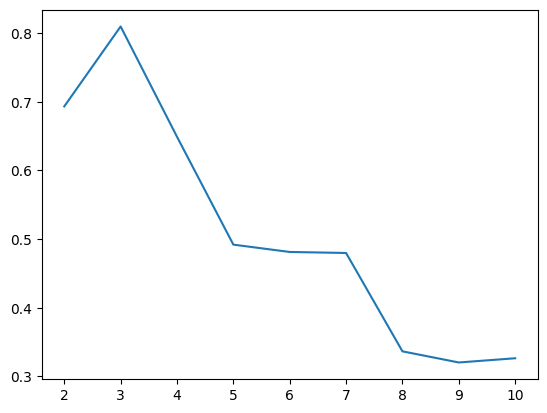

In [47]:
plt.plot(range(2,11),silhouette_coefficients)